In [1]:
import sys, re
sys.path.append('..')  # Adjust the path as per your directory structure

from scripts.constants import *
from scripts.logging_config import *

import pandas as pd
import geopandas as gpd
import numpy as np
import rioxarray as rxr
from rioxarray.merge import merge_arrays
import rasterio as rio
from rasterstats import zonal_stats

## Variables

In [11]:
# Variables
project_crs = 'EPSG:27700'

# IN paths
imd_lsoa_bua_boundaries_path = VECTOR_OUT_DIR / "IMD" / "English_IMD_2019_BUA_filtered_boundaries.geojson"
vom_dir = RASTER_IN_DIR / "Defra" / "VOM"
vom_lad_dir = vom_dir / "LADs"
vom_unzipped_dir = vom_dir / "unzipped_tiles"
vom_zipped_dir = vom_dir / "zipped_tiles"

imd_lsoa_bua_gdf = gpd.read_file(imd_lsoa_bua_boundaries_path).sort_values(by='LAD22CD')

In [14]:
len(imd_lsoa_bua_gdf[imd_lsoa_bua_gdf['LAD22CD'] == 'E06000001'])

58

In [3]:
# # Change name in files from csv DON'T RUN AGAIN!!!!!!
# import re, os
# file_names_lst = list(vom_lad_dir.glob('*.csv'))
# split_names_lst = [re.split('_|/', file_name.stem) for file_name in file_names_lst]
# split_names_lst
# lad_df = imd_lsoa_bua_gdf[['LAD22CD', 'LAD22NM']].drop_duplicates().reset_index(drop=True)
# lad_code = [lad_df[lad_df['LAD22NM'] == e[0]]['LAD22CD'].iloc[0] for e in split_names_lst]
# new_name = ['VOM_tiles_' + lad_code[i] + '.csv' for i in range(len(split_names_lst))]


# for old_name, x in zip(file_names_lst, new_name):
#     new_path = old_name.parent / x
#     print(new_path)
#     os.rename(old_name, new_path)

In [4]:
def classify_vom_type(file_name):
    if 'VOM_HS_' in file_name:
        return 'HS'
    else:
        return 'CHM'
    
def extract_grid_reference(filename):
    match = re.search(r'VOM(?:_HS)?_([A-Z]{2}\d{4})_', filename)
    if match:
        return match.group(1)
    return None

def translate_tile_name(tile_name: str) -> str:
    
    NS_dict = {'S': '0', 'N': '5'}
    EW_dict = {'W': '0', 'E': '5'} 

    assert len(tile_name) == 6
    
    code = tile_name[2:6].upper()
    try: # If input is like TL0045
        int(code)
        NS_dict = {v: k for k, v in NS_dict.items()}
        EW_dict = {v: k for k, v in EW_dict.items()}
        ns_id = code[3]
        ew_id = code[1]
        direction_code = code[0] + code[2] + NS_dict[ns_id] + EW_dict[ew_id]
        trans_tile_name = tile_name[:2].upper() + direction_code
    except ValueError: # If input is like TL04NW
        ns_id = code[2]
        ew_id = code[3]
        number_code = code[0] + EW_dict[ew_id] + code[1] + NS_dict[ns_id]
        trans_tile_name = tile_name[:2].lower() + number_code

    return trans_tile_name

def select_chm_files(geo_selected_vom_tiles_df, geo_vom_tiles_df, tif_paths_df,):

    selected_chm_path_lst = []
    for row in geo_selected_vom_tiles_df.itertuples():
        tile_name = translate_tile_name(row.TILE_NAME).upper()
        year = row.year
        temp_df = tif_paths_df[((tif_paths_df['TILE_NAME'] == tile_name) & (tif_paths_df['year'] == str(year))) & (tif_paths_df['file_type'] == 'CHM')]
        if len(temp_df) == 1:
            selected_chm_path_lst.append(Path(temp_df.path.iloc[0]))
        else:
            tile_df = geo_vom_tiles_df[geo_vom_tiles_df['TILE_NAME'] == row.TILE_NAME]
            tile_years_lst = tile_df.year.tolist()
            tile_years_lst.remove(year)
            ind = 0
            while len(tile_years_lst) > 0 and ind < len(tile_years_lst):
                temp_df = tif_paths_df[((tif_paths_df['TILE_NAME'] == tile_name) & (tif_paths_df['year'] == str(tile_years_lst[ind]))) & (tif_paths_df['file_type'] == 'CHM')]
                if len(temp_df) == 1:
                    selected_chm_path_lst.append(Path(temp_df.path.iloc[0]))
                    ind = len(tile_years_lst) + 1
                else:
                    ind += 1

    return selected_chm_path_lst

In [ ]:
geo_level = 'LAD22CD'
geo_code = 'E07000008'
def prepare_geo_data(geo_level, geo_code, imd_lsoa_bua_gdf):

    subgeo_filt_gdf = imd_lsoa_bua_gdf.copy()[imd_lsoa_bua_gdf[geo_level].isin([geo_code])].reset_index(drop=True)
    geo_boundary_gdf = subgeo_filt_gdf.dissolve()[['geometry', geo_level]]

    geo_vom_tiles_path = vom_lad_dir / f"VOM_tiles_{geo_code}.csv"
    geo_vom_tiles_df = pd.read_csv(geo_vom_tiles_path).sort_values(['TILE_NAME', 'year'], ascending=[True, False])
    geo_selected_vom_tiles_df = geo_vom_tiles_df.groupby(['TILE_NAME']).first().reset_index()

    tif_paths = list(vom_unzipped_dir.rglob("*.tif"))
    tif_paths_lst = [[path.parent.name, extract_grid_reference(path.name), classify_vom_type(path.name), str(path)] for path in tif_paths]

    tif_paths_df = pd.DataFrame(tif_paths_lst, columns=['year', 'TILE_NAME', 'file_type', 'path']).sort_values(['TILE_NAME', 'year']).reset_index(drop=True)
    
    return subgeo_filt_gdf, geo_boundary_gdf, geo_selected_vom_tiles_df, tif_paths_df

# subgeo_filt_gdf, geo_boundary_gdf, geo_selected_vom_tiles_df, tif_paths_df = prepare_geo_data(geo_level, geo_code, imd_lsoa_bua_gdf, vom_lad_dir, vom_unzipped_dir)
# subgeo_filt_gdf = imd_lsoa_bua_gdf.copy()[imd_lsoa_bua_gdf[geo_level].isin([geo_code])].reset_index(drop=True)
# geo_boundary_gdf = subgeo_filt_gdf.dissolve()[['geometry', geo_level]]

# geo_vom_tiles_path = vom_lad_dir / f"VOM_tiles_{geo_code}.csv"
# geo_vom_tiles_df = pd.read_csv(geo_vom_tiles_path).sort_values(['TILE_NAME', 'year'], ascending=[True, False])
# geo_selected_vom_tiles_df = geo_vom_tiles_df.groupby(['TILE_NAME']).first().reset_index()

# tif_paths = list(vom_unzipped_dir.rglob("*.tif"))
# tif_paths_lst = [[path.parent.name, extract_grid_reference(path.name), classify_vom_type(path.name), str(path)] for path in tif_paths]

# tif_paths_df = pd.DataFrame(tif_paths_lst, columns=['year', 'TILE_NAME', 'file_type', 'path']).sort_values(['TILE_NAME', 'year']).reset_index(drop=True)

In [82]:
selected_chm_path_lst = select_chm_files(geo_selected_vom_tiles_df, geo_vom_tiles_df, tif_paths_df)

In [ ]:
chm_xr_lst = [rxr.open_rasterio(file) for file in selected_chm_path_lst]
merged_chm_xr = merge_arrays(chm_xr_lst)

In [60]:
low_threshold = 3
high_threshold = 60

binary_merged_chm_xr = (merged_chm_xr >= low_threshold) & (merged_chm_xr <= high_threshold)
binary_merged_chm_xr = binary_merged_chm_xr.astype(int).fillna(0)
binary_merged_chm_xr

<xarray.DataArray (band: 1, y: 15000, x: 10000)> Size: 1GB
array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]]])
Coordinates:
  * x            (x) float64 80kB 5.4e+05 5.4e+05 5.4e+05 ... 5.5e+05 5.5e+05
  * y            (y) float64 120kB 2.65e+05 2.65e+05 ... 2.5e+05 2.5e+05
    spatial_ref  int64 8B 0
  * band         (band) int64 8B 1

In [ ]:
def binarise_tiles(selected_chm_path_lst, low_threshold, high_threshold):
    chm_xr_lst = [rxr.open_rasterio(file) for file in selected_chm_path_lst]
    merged_chm_xr = merge_arrays(chm_xr_lst)

    binary_merged_chm_xr = (merged_chm_xr >= low_threshold) & (merged_chm_xr <= high_threshold)
    binary_merged_chm_xr = binary_merged_chm_xr.astype(int).fillna(0)

    return binary_merged_chm_xr

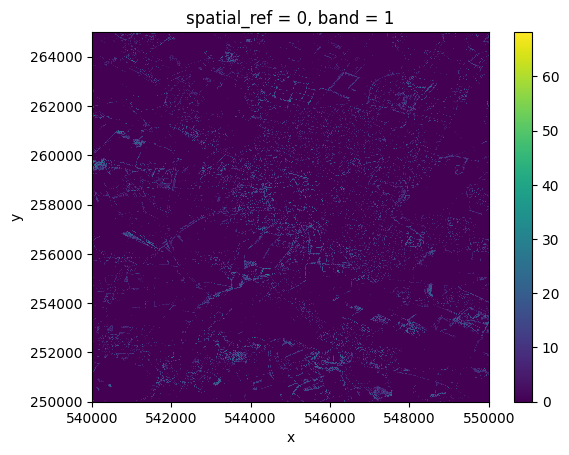

In [ ]:
merged_chm_xr.plot()

In [80]:
# Calculate zonal statistics with categorical parameter
zs_categorical = zonal_stats(subgeo_filt_gdf, binary_merged_chm_xr[0].values, 
                             affine=merged_chm_xr.rio.transform(), categorical=True)

subgeo_filt_gdf['canopy_cover'] = [round(100 * z.get(1, 0) / (z.get(0, 0) + z.get(1, 0)), 2) for z in zs_categorical]

variables_to_keep = ['LSOA11CD', 'LSOA21CD', geo_level ,'canopy_cover']

subgeo_canopy_cover_df = subgeo_filt_gdf.copy()[variables_to_keep]
subgeo_canopy_cover_df

,LSOA11CD,LSOA21CD,LAD22CD,canopy_cover
0,E01017943,E01017943,E07000008,6.55
1,E01017944,E01017944,E07000008,8.30
2,E01017945,E01017945,E07000008,15.11
3,E01017946,E01017946,E07000008,9.31
4,E01017947,E01017947,E07000008,9.55
...,...,...,...,...
64,E01032792,E01032792,E07000008,17.74
65,E01032794,E01032794,E07000008,18.71
66,E01032795,E01035523,E07000008,13.74
67,E01032797,E01035515,E07000008,14.28


In [ ]:
def get_canopy_cover(subgeo_filt_gdf, binary_merged_chm_xr):

    zs_categorical = zonal_stats(subgeo_filt_gdf, binary_merged_chm_xr[0].values, 
                                affine=merged_chm_xr.rio.transform(), categorical=True)

    subgeo_filt_gdf['canopy_cover'] = [round(100 * z.get(1, 0) / (z.get(0, 0) + z.get(1, 0)), 2) for z in zs_categorical]

    variables_to_keep = ['LSOA11CD', 'LSOA21CD', geo_level ,'canopy_cover']

    subgeo_canopy_cover_df = subgeo_filt_gdf.copy()[variables_to_keep]
    
    return subgeo_canopy_cover_df